In [2]:
from pathlib import Path

BASE = Path("../data/datasets_full.csv")

for p in sorted(BASE.rglob("users.csv")):
    print(p)
    

..\data\datasets_full.csv\genuine_accounts.csv\users.csv
..\data\datasets_full.csv\social_spambots_1.csv\users.csv
..\data\datasets_full.csv\traditional_spambots_1.csv\users.csv


In [3]:
import pandas as pd

genuine = pd.read_csv(BASE / "genuine_accounts.csv" / "users.csv")
social  = pd.read_csv(BASE / "social_spambots_1.csv" / "users.csv")
trad    = pd.read_csv(BASE / "traditional_spambots_1.csv" / "users.csv")

print("genuine:", genuine.shape)
print("social spambots:", social.shape)
print("traditional spambots:", trad.shape)

genuine.head()

genuine: (3474, 42)
social spambots: (991, 41)
traditional spambots: (1000, 40)


,id,name,screen_name,statuses_count,followers_count,friends_count,favourites_count,listed_count,url,lang,...,notifications,description,contributors_enabled,following,created_at,timestamp,crawled_at,updated,test_set_1,test_set_2
0,1502026416,TASUKU HAYAKAWA,0918Bask,2177,208,332,265,1,NaN,ja,...,NaN,15years ago X.Lines24,NaN,NaN,Tue Jun 11 11:20:35 +0000 2013,2013-06-11 13:20:35,2015-05-02 06:41:46,2016-03-15 15:53:47,0,0
1,2492782375,ro_or,1120Roll,2660,330,485,3972,5,NaN,ja,...,NaN,保守見習い地元大好き人間。 経済学、電工、仏教を勉強中、ちなDeではいかんのか？ (*^◯^*),NaN,NaN,Tue May 13 10:37:57 +0000 2014,2014-05-13 12:37:57,2015-05-01 17:20:27,2016-03-15 15:53:48,0,0
2,293212315,bearclaw,14KBBrown,1254,166,177,1185,0,NaN,en,...,NaN,Let me see what your best move is!,NaN,NaN,Wed May 04 23:30:37 +0000 2011,2011-05-05 01:30:37,2015-05-01 18:48:28,2016-03-15 15:53:48,0,0
3,191839658,pocahontas farida,wadespeters,202968,2248,981,60304,101,http://t.co/rGV0HIJGsu,en,...,NaN,20. menna: #farida #nyc and the 80s actually y...,NaN,NaN,Fri Sep 17 14:02:10 +0000 2010,2010-09-17 16:02:10,2015-05-01 13:55:16,2016-03-15 15:53:48,0,0
4,3020965143,Ms Kathy,191a5bd05da04dc,82,21,79,5,0,NaN,en,...,NaN,Cosmetologist,NaN,NaN,Fri Feb 06 04:10:49 +0000 2015,2015-02-06 05:10:49,2015-05-02 01:17:32,2016-03-15 15:53:48,0,0


In [4]:
FEATURES = [
    "statuses_count", "followers_count", "friends_count",
    "favourites_count", "listed_count",
]

def prep(df, label, source):
    out = df[FEATURES].copy()
    out["label"] = label          # 1 = bot, 0 = human
    out["source"] = source
    return out

data = pd.concat([
    prep(genuine, 0, "genuine"),
    prep(social,  1, "social_spambot_1"),
    prep(trad,    1, "traditional_spambot_1"),
], ignore_index=True)

data = data.fillna(0)

print(data.shape)
print(data["label"].value_counts())
data.head()

(5465, 7)
label
0    3474
1    1991
Name: count, dtype: int64


,statuses_count,followers_count,friends_count,favourites_count,listed_count,label,source
0,2177,208,332,265,1,0,genuine
1,2660,330,485,3972,5,0,genuine
2,1254,166,177,1185,0,0,genuine
3,202968,2248,981,60304,101,0,genuine
4,82,21,79,5,0,0,genuine


In [5]:
summary = data.groupby("label")[FEATURES].median()
summary.index = ["human (0)", "bot (1)"]
print(summary.T)

print()
print(data.groupby("source")[FEATURES].median().T)

                  human (0)  bot (1)
statuses_count       6609.0     75.0
followers_count       341.0    206.0
friends_count         319.0    750.0
favourites_count     1286.0      0.0
listed_count            2.0      1.0

source            genuine  social_spambot_1  traditional_spambot_1
statuses_count     6609.0             138.0                   16.0
followers_count     341.0             234.0                  198.5
friends_count       319.0             313.0                  956.0
favourites_count   1286.0               0.0                    0.0
listed_count          2.0               0.0                    1.0


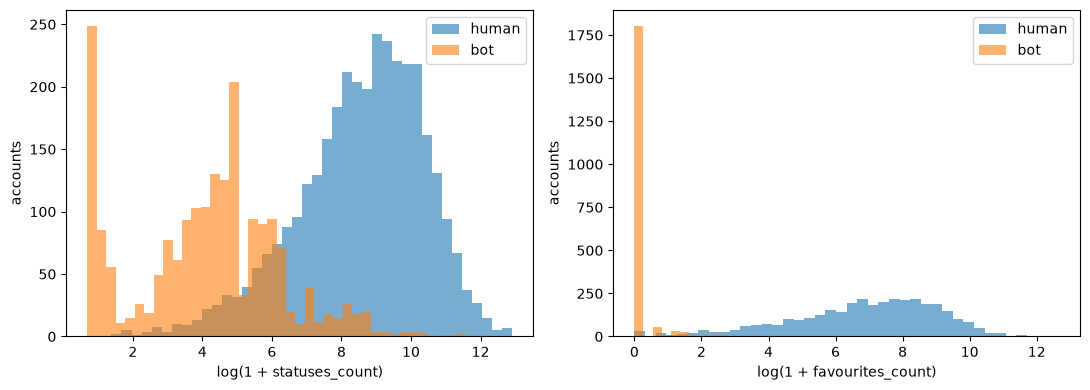

In [7]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, feat in zip(axes, ["statuses_count", "favourites_count"]):
    for lab, name in [(0, "human"), (1, "bot")]:
        vals = data.loc[data["label"] == lab, feat]
        ax.hist(np.log1p(vals), bins=40, alpha=0.6, label=name)
    ax.set_xlabel(f"log(1 + {feat})")
    ax.set_ylabel("accounts")
    ax.legend()

fig.tight_layout()
fig.savefig("../figures/fig1_feature_distributions.png", dpi=200)
plt.show()

In [8]:
fig.suptitle("Feature distributions by class (log scale)")
fig.savefig("../figures/fig1_feature_distributions.png", dpi=200, bbox_inches="tight")

In [10]:
from sklearn.model_selection import train_test_split

X = data[FEATURES]
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

print("train:", X_train.shape, " test:", X_test.shape)
print("train bot rate:", round(y_train.mean(), 3))
print("test  bot rate:", round(y_test.mean(), 3))

train: (4098, 5)  test: (1367, 5)
train bot rate: 0.364
test  bot rate: 0.364


In [11]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

logreg = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=42),
)

logreg.fit(X_train, y_train)
pred_lr = logreg.predict(X_test)

print(classification_report(y_test, pred_lr, target_names=["human", "bot"], digits=3))

              precision    recall  f1-score   support

       human      0.981     0.881     0.928       869
         bot      0.824     0.970     0.891       498

    accuracy                          0.914      1367
   macro avg      0.903     0.926     0.910      1367
weighted avg      0.924     0.914     0.915      1367



In [12]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print(classification_report(y_test, pred_rf, target_names=["human", "bot"], digits=3))

              precision    recall  f1-score   support

       human      0.974     0.993     0.983       869
         bot      0.988     0.954     0.970       498

    accuracy                          0.979      1367
   macro avg      0.981     0.973     0.977      1367
weighted avg      0.979     0.979     0.979      1367



                 model  accuracy  precision_bot  recall_bot  f1_bot
0  Logistic Regression     0.914          0.824       0.970   0.891
1        Random Forest     0.979          0.988       0.954   0.970


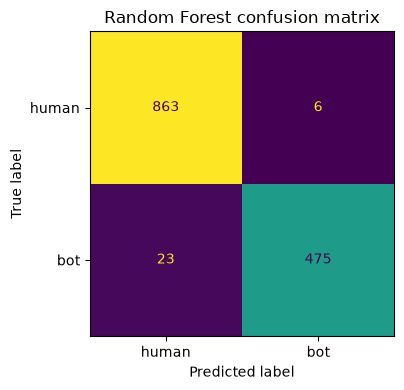

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

def scores(name, y_true, y_pred):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_bot": precision_score(y_true, y_pred),
        "recall_bot": recall_score(y_true, y_pred),
        "f1_bot": f1_score(y_true, y_pred),
    }

results = pd.DataFrame([
    scores("Logistic Regression", y_test, pred_lr),
    scores("Random Forest", y_test, pred_rf),
]).round(3)

results.to_csv("../figures/table1_results.csv", index=False)
print(results)

fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_rf, display_labels=["human", "bot"], ax=ax, colorbar=False
)
ax.set_title("Random Forest confusion matrix")
fig.tight_layout()
fig.savefig("../figures/fig2_confusion_matrix.png", dpi=200)
plt.show()